In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_sec = pd.read_csv('metricas_secuencial.csv')
df_conc = pd.read_csv('metricas_concurrente.csv')

In [9]:
#Tiempo promedio de cada modelo
tiempo_promedio_sec = df_sec['tiempo_segundos'].mean()
tiempo_promedio_conc = df_conc['tiempo_segundos'].mean()
print(f'Tiempo promedio secuencial: {tiempo_promedio_sec:.2f} segundos')
print(f'Tiempo promedio concurrente: {tiempo_promedio_conc:.2f} segundos')

Tiempo promedio secuencial: 1500.05 segundos
Tiempo promedio concurrente: 27.94 segundos


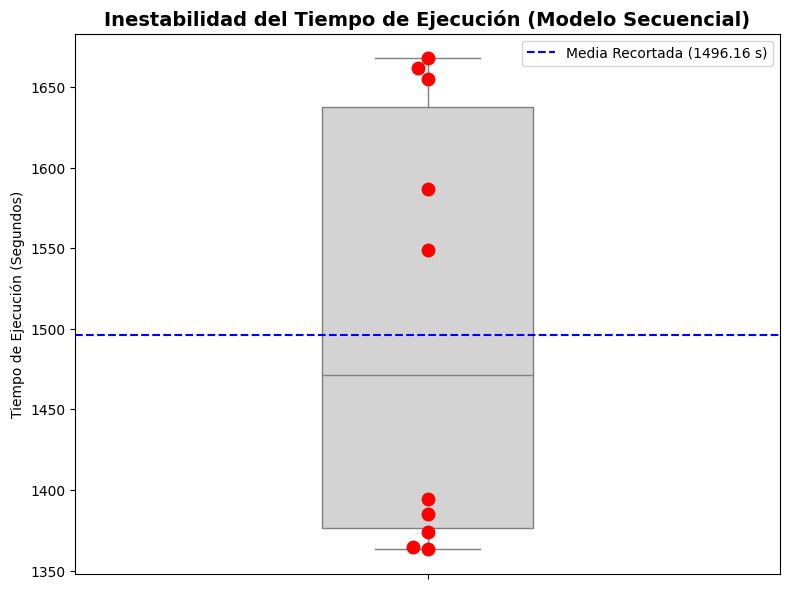

In [4]:
# Cálculo de la línea base (Media Recortada del secuencial)
# Ordenamos, quitamos el mayor y el menor para evitar ruido del SO
tiempos_ordenados = df_sec['tiempo_segundos'].sort_values()
media_secuencial = tiempos_ordenados.iloc[1:-1].mean()

# ==========================================
# GRÁFICA 1: Variabilidad del Modelo Secuencial (Boxplot y Swarmplot)
# ==========================================
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_sec['tiempo_segundos'], color='lightgray', width=0.3)
sns.swarmplot(y=df_sec['tiempo_segundos'], color='red', size=10)
plt.axhline(media_secuencial, color='blue', linestyle='--', label=f'Media Recortada ({media_secuencial:.2f} s)')
plt.title('Inestabilidad del Tiempo de Ejecución (Modelo Secuencial)', fontsize=14, fontweight='bold')
plt.ylabel('Tiempo de Ejecución (Segundos)')
plt.legend()
plt.tight_layout()
plt.savefig('grafica_1_variabilidad_secuencial.png')
plt.show()

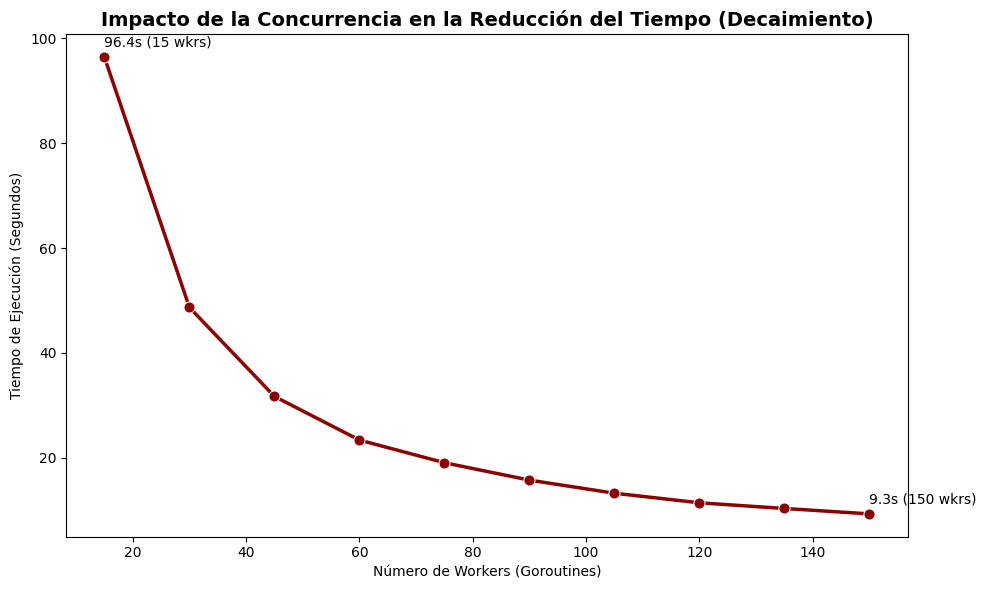

In [5]:
# ==========================================
# GRÁFICA 2: Decaimiento Exponencial del Tiempo (Curva de Rendimiento)
# ==========================================
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_conc, x='goroutines', y='tiempo_segundos', marker='o', markersize=8, color='darkred', linewidth=2.5)
plt.title('Impacto de la Concurrencia en la Reducción del Tiempo (Decaimiento)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Workers (Goroutines)')
plt.ylabel('Tiempo de Ejecución (Segundos)')
# Anotaciones de los extremos
plt.text(15, 96.4 + 2, '96.4s (15 wkrs)')
plt.text(150, 9.3 + 2, '9.3s (150 wkrs)')
plt.tight_layout()
plt.savefig('grafica_2_decaimiento_tiempo.png')
plt.show()

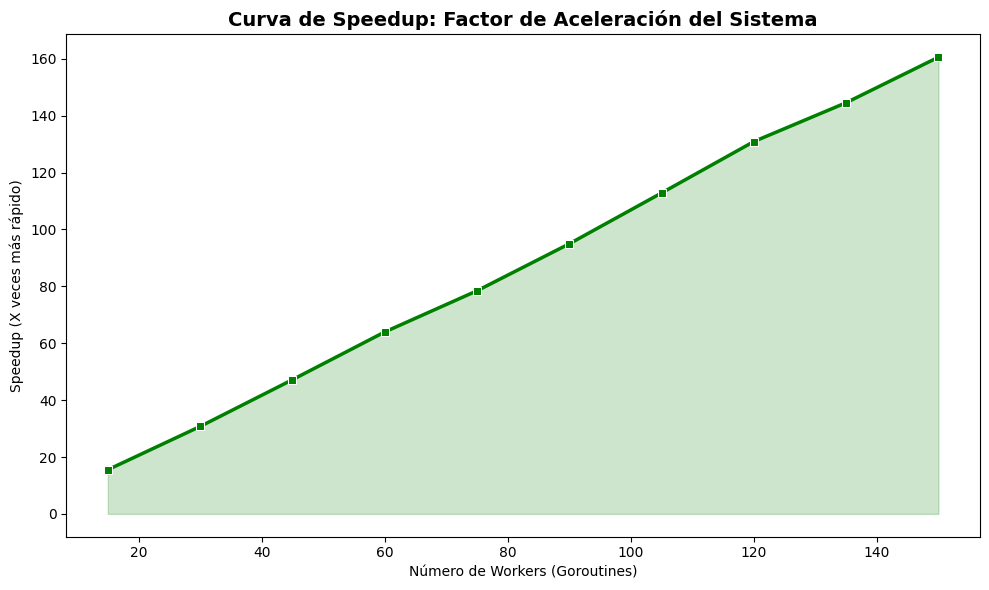

In [6]:
# ==========================================
# GRÁFICA 3: Curva de Speedup (Factor de Aceleración)
# ==========================================
# Speedup = T_secuencial_base / T_concurrente
df_conc['speedup'] = media_secuencial / df_conc['tiempo_segundos']

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_conc, x='goroutines', y='speedup', marker='s', color='green', linewidth=2.5)
plt.fill_between(df_conc['goroutines'], df_conc['speedup'], alpha=0.2, color='green')
plt.title('Curva de Speedup: Factor de Aceleración del Sistema', fontsize=14, fontweight='bold')
plt.xlabel('Número de Workers (Goroutines)')
plt.ylabel('Speedup (X veces más rápido)')
plt.tight_layout()
plt.savefig('grafica_3_curva_speedup.png')
plt.show()

C:\Users\bruno\AppData\Local\Temp\ipykernel_30772\1550088186.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_conc['goroutines'].astype(str), y=df_conc['ahorro_tiempo'], palette='viridis')


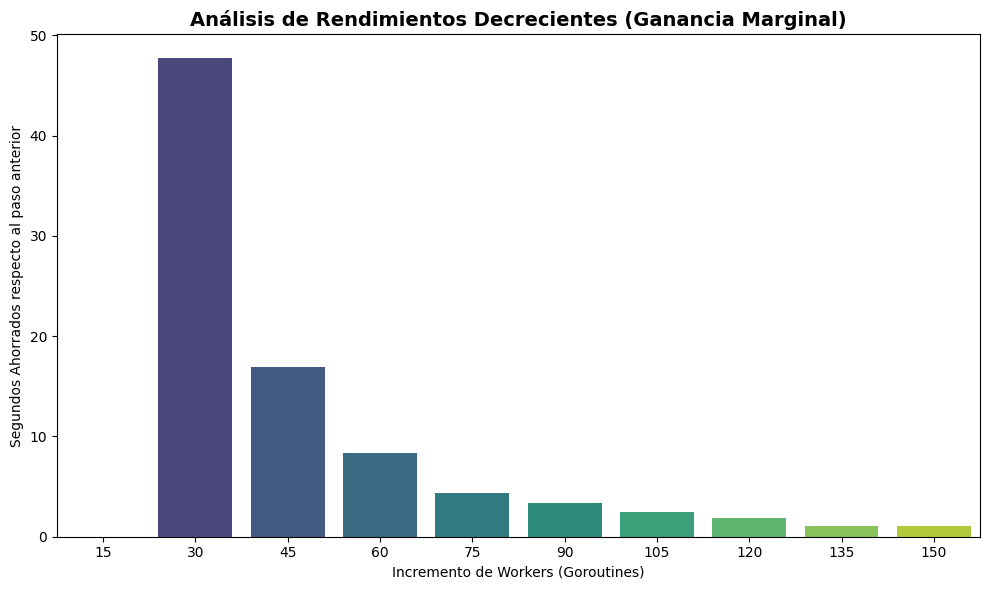

In [7]:
# ==========================================
# GRÁFICA 4: Análisis de Ganancia Marginal (Rendimientos Decrecientes)
# ==========================================
# Calculamos cuánto tiempo "ahorramos" por cada bloque de 15 workers adicionales
df_conc['ahorro_tiempo'] = df_conc['tiempo_segundos'].shift(1) - df_conc['tiempo_segundos']
df_conc['ahorro_tiempo'] = df_conc['ahorro_tiempo'].fillna(0)

plt.figure(figsize=(10, 6))
sns.barplot(x=df_conc['goroutines'].astype(str), y=df_conc['ahorro_tiempo'], palette='viridis')
plt.title('Análisis de Rendimientos Decrecientes (Ganancia Marginal)', fontsize=14, fontweight='bold')
plt.xlabel('Incremento de Workers (Goroutines)')
plt.ylabel('Segundos Ahorrados respecto al paso anterior')
plt.tight_layout()
plt.savefig('grafica_4_rendimientos_decrecientes.png')
plt.show()